In [38]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
dict_path = R"data/caueeg/caueeg-dataset/dementia.json"
with open(dict_path) as f:
    subj_dict = json.load(f)

In [15]:
bins = np.arange(0, 100, 5)
ages = []
for s in ["train_split"]:
    for subj in subj_dict[s]:
        ages.append(subj['age'])

Text(0.5, 1.0, 'Binned subject ages (bin width = 5)')

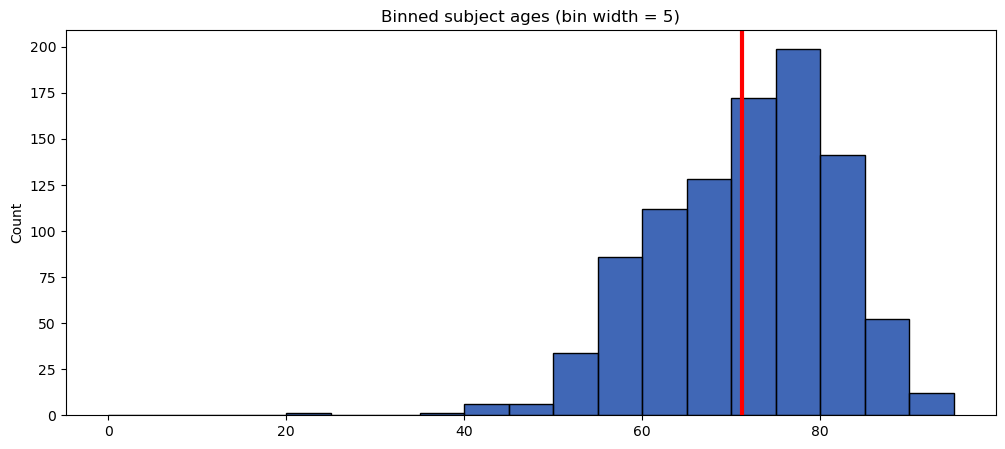

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(ages, color='#00349E', bins=bins, ax=ax)
ax.axvline(np.mean(ages), color='r', lw=3)
ax.set_title("Binned subject ages (bin width = 5)")

In [ ]:
# Get the average age and std per diagnostic category, as well as the average sex distribution per diagnostic category, do this for train, val and test set
count=0
train_ages = {0: [], 1: [], 2:[]}

for subj in subj_dict['train_split']:
    count+=1
    train_ages[subj['class_label']].append(subj['age'])
print(count)

print("HC mean:", np.mean(train_ages[0]))
print("HC std:", np.std(train_ages[0], ddof=1))
print("HC Count:", len(train_ages[0]))

print("MCI mean:", np.mean(train_ages[1]))
print("MCI std:", np.std(train_ages[1], ddof=1))
print("MCI Count:", len(train_ages[1]))

print("DEM mean:", np.mean(train_ages[2]))
print("DEM std:", np.std(train_ages[2], ddof=1))
print("DEM Count:", len(train_ages[2]))


950
HC mean: 65.36784741144415
HC std: 9.476652443166083
HC Count: 367
MCI mean: 73.71556886227545
MCI std: 7.8323229254261895
MCI Count: 334
DEM mean: 76.59437751004016
DEM std: 8.012598982457922
DEM Count: 249


In [ ]:
val_ages = {0: [], 1: [], 2:[]}
count = 0

for subj in subj_dict['validation_split']:
    count+=1
    val_ages[subj['class_label']].append(subj['age'])
print(count)
print("HC mean:", np.mean(val_ages[0]))
print("HC std:", np.std(val_ages[0], ddof=1))
print("HC Count:", len(val_ages[0]))

print("MCI mean:", np.mean(val_ages[1]))
print("MCI std:", np.std(val_ages[1], ddof=1))
print("MCI Count:", len(val_ages[1]))

print("DEM mean:", np.mean(val_ages[2]))
print("DEM std:", np.std(val_ages[2], ddof=1))
print("DEM Count:", len(val_ages[2]))

119
HC mean: 64.91304347826087
HC std: 10.43887198451915
HC Count: 46
MCI mean: 75.02380952380952
MCI std: 7.137971616089701
MCI Count: 42
DEM mean: 77.25806451612904
DEM std: 9.574158768739542
DEM Count: 31


In [ ]:
test_ages = {0: [], 1: [], 2:[]}
count = 0

for subj in subj_dict['test_split']:
    count +=1
    test_ages[subj['class_label']].append(subj['age'])
print(count)
print("HC mean:", np.mean(test_ages[0]))
print("HC std:", np.std(test_ages[0], ddof=1))
print("HC Count:", len(test_ages[0]))

print("MCI mean:", np.mean(test_ages[1]))
print("MCI std:", np.std(test_ages[1], ddof=1))
print("MCI Count:", len(test_ages[1]))

print("DEM mean:", np.mean(test_ages[2]))
print("DEM std:", np.std(test_ages[2], ddof=1))
print("DEM Count:", len(test_ages[2]))


118
HC mean: 63.21739130434783
HC std: 8.437780233313765
HC Count: 46
MCI mean: 72.7560975609756
MCI std: 8.572573965282766
MCI Count: 41
DEM mean: 76.35483870967742
DEM std: 7.176574796269569
DEM Count: 31


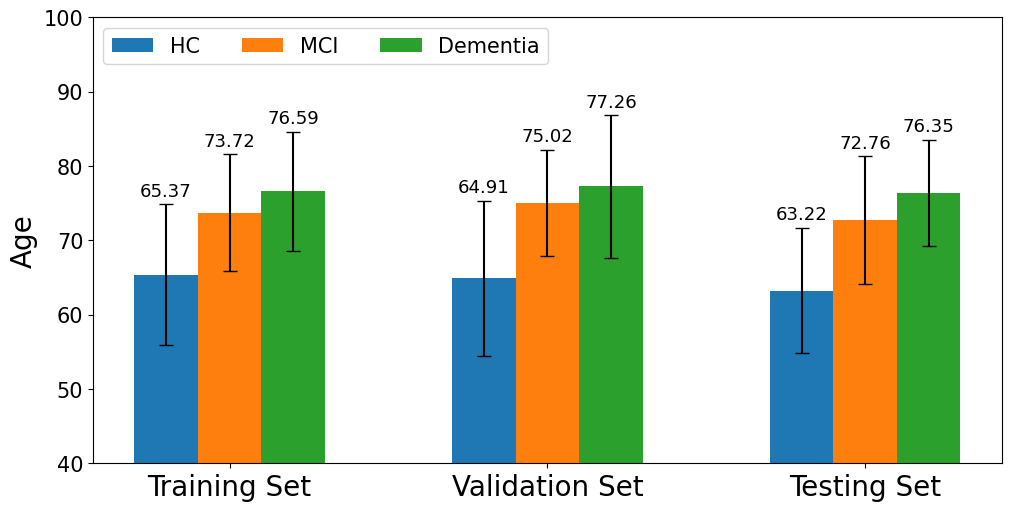

In [ ]:
splits = ("Training Set", "Validation Set", "Testing Set")
all_means = {
    "HC": [np.mean(train_ages[0]), np.mean(val_ages[0]), np.mean(test_ages[0])],
    "MCI": [np.mean(train_ages[1]), np.mean(val_ages[1]), np.mean(test_ages[1])],
    "Dementia": [np.mean(train_ages[2]), np.mean(val_ages[2]), np.mean(test_ages[2])],
}

all_stds ={
    "HC": [np.std(train_ages[0], ddof=1), np.std(val_ages[0], ddof=1), np.std(test_ages[0], ddof=1)],
    "MCI": [np.std(train_ages[1], ddof=1), np.std(val_ages[1], ddof=1), np.std(test_ages[1], ddof=1)],
    "Dementia": [np.std(train_ages[2], ddof=1), np.std(val_ages[2], ddof=1), np.std(test_ages[2], ddof=1)],
}

x = np.arange(len(splits))  # the label locations
width = 0.20  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(10, 5))

for attribute, measurement in all_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, [round(x, 2) for x in measurement], width, label=attribute, yerr=all_stds[attribute], capsize=5)
    ax.bar_label(rects, padding=3, fontsize=13)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Age', fontsize=20)
ax.set_xticks(x + width, splits, fontsize=20)
ax.legend(loc='upper left', ncols=3, prop={'size':15})
ax.set_ylim(40, 100)
ax.tick_params(axis='y', labelsize=15)

# plt.show()
plt.savefig('./age_bar.png')